## Utrecht University - Network Science

### Community Detecion in the European Football Transfer Market

The data is obtained from the following repository: https://github.com/ewenme/transfers/tree/master. The data is provided as csv files and it is freely available to actively encourage new research and analysis at all levels in Football Analytics. The structure of the data is the following:

> English Premier League (premier-league.csv)

> English Championship (championship.csv)

> French Ligue 1 (ligue-1.csv)

>German 1.Bundesliga (1-bundesliga.csv)

>Italian Serie A (serie-a.csv)

>Spanish La Liga (primera-division.csv)

>Portugese Liga NOS (liga-nos.csv)

>Dutch Eredivisie (eredivisie.csv)

>Russian Premier Liga (premier-liga.csv)

Each dataset has the following common variables:




<div style="display: flex; justify-content: center; align-items: flex-start; gap: 20px; height: 350px;">
  <div style="height: 100%;">
    <img src="variables_transfer_data.jpg" style="height: 100%; object-fit: contain;">


### 1. Data Loading and Exploration

In [2]:
import pandas as pd
import numpy as np


path = "premier-league.csv"

dataframe = pd.read_csv(path)

dataframe[dataframe['player_name'] == 'Gonçalo Guedes']

,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country
23468,Wolverhampton Wanderers,Gonçalo Guedes,25.0,Left Winger,Valencia,€32.60m,in,Summer,32.6,Premier League,2022,2022/2023,England
23673,Wolverhampton Wanderers,Gonçalo Guedes,26.0,Second Striker,Benfica,loan transfer,out,Winter,NaN,Premier League,2022,2022/2023,England


In [3]:
path2 = "primera-division.csv"

dataframe2 = pd.read_csv(path2)

dataframe2[dataframe2['player_name'] == 'Gonçalo Guedes']

,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country
13229,Valencia CF,Gonçalo Guedes,20.0,Left Winger,Paris SG,loan transfer,in,Summer,NaN,Primera Division,2017,2017/2018,Spain
14136,Valencia CF,Gonçalo Guedes,21.0,Left Winger,Paris SG,€40.00m,in,Summer,40.0,Primera Division,2018,2018/2019,Spain
14166,Valencia CF,Gonçalo Guedes,21.0,Left Winger,Paris SG,"End of loanJun 30, 2018",out,Summer,NaN,Primera Division,2018,2018/2019,Spain
16872,Valencia CF,Gonçalo Guedes,25.0,Left Winger,Wolves,€32.60m,out,Summer,32.6,Primera Division,2022,2022/2023,Spain


In [4]:
path3 = "liga-nos.csv"

dataframe3 = pd.read_csv(path3)

dataframe3[dataframe3['player_name'] == 'Gonçalo Guedes']

,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country
14011,SL Benfica,Gonçalo Guedes,18.0,Left Winger,Benfica B,-,in,Winter,NaN,Liga Nos,2014,2014/2015,Portugal
15996,SL Benfica,Gonçalo Guedes,20.0,Left Winger,Paris SG,€30.00m,out,Winter,30.0,Liga Nos,2016,2016/2017,Portugal
21572,SL Benfica,Gonçalo Guedes,26.0,Second Striker,Wolves,loan transfer,in,Winter,NaN,Liga Nos,2022,2022/2023,Portugal


By exploring the dataset, we can see how the transfers are recorded in the data.

Basically every transfer movement is recorded for each club in each league. 
> When the _transfer_movement_ variable has "in" value, it means that the player has signed for the club that figures in the _club_name_ field. 

> When the _transfer_movement_ variable has "out" value, it means that the player has signed for the club that figures in the _club_involved_name_ field. 

Also, its important to notice that the same transfer, will be recorded twice in the data, as it will figure both in the dataset for the buying club, and in the dataset for the selling club. Above we can see an example of the transfer involving Valencia CF and Wolverhampton Wonderers for the player Gonçalo Guedes. 
The instance is registered both in the dataset for the spanish la liga transfers and english premier league transfers.

Overall, the transfers produced between clubs will be accounted twice, but that does not require any treatment as it will be the same for all transfers with all the clubs involved in the data, so at the end the duplicity will have no effect or bias, as it will be present throughout all the connections between clubs. An alternative way to solve this duplicity is simply filtering all the registers from the final unified dataset, that belong to _transfer_movement_ "in".

Another important point is to notice the Data-Quality of the club names present in the data. We can see how the same club (Wolverhampton Wonderers), has different naming formats. While in the premier league dataset is written as "Wolverhampton Wonderers", in the spanish dataset is written as "Wolves". This is an issue we have to solve before hand. We will normalize the namings of all the different clubs present in all the datasets.

In [5]:
# List of all the file paths we have as data

path_english_premier_league = "premier-league.csv"
path_english_championship = "championship.csv"
path_french_ligue1 = "ligue-1.csv"
path_german_bundesliga = "1-bundesliga.csv"
path_italian_serieA = "serie-a.csv"
path_spanish_laliga = "primera-division.csv"
path_portugese_ligaNOS = "liga-nos.csv"
path_dutch_eredivisie = "eredivisie.csv"
path_russian_premier_liga = "premier-liga.csv"

In [6]:
df_english_premier_league = pd.read_csv(path_english_premier_league)
df_english_championship = pd.read_csv(path_english_championship)
df_french_ligue1 = pd.read_csv(path_french_ligue1)
df_german_bundesliga = pd.read_csv(path_german_bundesliga)
df_italian_serieA = pd.read_csv(path_italian_serieA)
df_spanish_laliga = pd.read_csv(path_spanish_laliga)
df_portugese_ligaNOS = pd.read_csv(path_portugese_ligaNOS)
df_dutch_eredivisie = pd.read_csv(path_dutch_eredivisie)
df_russian_premier_liga = pd.read_csv(path_russian_premier_liga)

In [7]:
# Collecting all the different club names present in the data

# Storing all dataframes in a list
dfs = [
    df_english_premier_league,
    df_english_championship,
    df_french_ligue1,
    df_german_bundesliga,
    df_italian_serieA,
    df_spanish_laliga,
    df_portugese_ligaNOS,
    df_dutch_eredivisie,
    df_russian_premier_liga
]

# Collecting all unique club names from both columns
clubs = set()

for df in dfs:
    clubs.update(df["club_name"].dropna().unique())
    clubs.update(df["club_involved_name"].dropna().unique())

# Sorting alphabetically for inspection
clubs = sorted(clubs)

print(f"Total unique club names: {len(clubs)}")

Total unique club names: 6386


In [8]:
# clubs

In [9]:
# We filter out all the youth system teams for each club (check how many youth system teams we have)

import re

# Pattern for youth teams: U16, U17, U18, U19, U20, U21
u_team_pattern = r"\bU(16|17|18|19|20|21)\b"

# Clubs that match this pattern
u_teams = [club for club in clubs if re.search(u_team_pattern, str(club), flags=re.IGNORECASE)]

print(f"Number of U16-U21 club names: {len(u_teams)}")
u_teams[:20]

Number of U16-U21 club names: 526


['1.FC Köln U19',
 'ADO U19',
 'ADO U21',
 'AJ Auxerre U19',
 'APC U20',
 'AS Cannes U19',
 'AS Nancy U19',
 'AZ Alkmaar U17',
 'AZ Alkmaar U19',
 'AZ Alkmaar U21',
 'AZ U18',
 'Aachen U19',
 'Académica U19',
 'Ajax U18',
 'Ajax U19',
 'Ajax U21',
 'Alavés U19',
 'Albacete U19',
 'Almere City U21',
 'Alverca U19']

In [10]:
# We will still use the transactions between clubs even if they are for the youth systems
clubs_without_u_teams = clubs

# In case we would like to create a new list without those clubs

# [
#     club for club in clubs
#     if not re.search(u_team_pattern, str(club), flags=re.IGNORECASE)
# ]

# print(f"Original clubs: {len(clubs)}")
# print(f"After removing U16-U21 clubs: {len(clubs_without_u_teams)}")
# print(f"Removed: {len(clubs) - len(clubs_without_u_teams)}")

In [11]:
# Applying some data engineering techniques to solve data-quality problems regarding different namings of a same club

# If needed:
!pip install rapidfuzz

from rapidfuzz import process, fuzz

clubs_clean_base = clubs_without_u_teams


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# Applying the functionallity of the library to extract fuzzy matchings from a set, with a certain word
process.extract(
    "Wolves",
    clubs_clean_base,
    scorer=fuzz.WRatio,
    limit=15
)

[('Wolves', 100.0, 6220),
 ('Wolves FC', 90.0, 6221),
 ('Wolves Res.', 90.0, 6222),
 ('Wolves U18', 90.0, 6223),
 ('Wolves U21', 90.0, 6224),
 ('Wolves U23', 90.0, 6225),
 ('Wolverhampton Wanderers', 81.81818181818181, 6219),
 ('Wolvega', 76.92307692307692, 6218),
 ('Ilves', 72.72727272727273, 2847),
 ('Bento Gonçalves', 72.0, 798),
 ('CD Mostoles', 72.0, 1092),
 ('Silves FC', 68.4, 5109),
 ('Novese', 66.66666666666667, 3915),
 ('Albion Rovers', 65.45454545454547, 364),
 ('Barton Rovers', 65.45454545454547, 741)]

In [13]:
# To search different duplicated candidates in fast and automated way
def find_similar_clubs(club_name, limit=15):
    return process.extract(
        club_name,
        clubs_clean_base,
        scorer=fuzz.WRatio,
        limit=limit
    )

In [14]:
find_similar_clubs("Man Utd")

[('Man Utd', 100.0, 3517),
 ('Man Utd Res.', 90.0, 3518),
 ('Man Utd U18', 90.0, 3519),
 ('Man Utd U21', 90.0, 3520),
 ('Man Utd U23', 90.0, 3521),
 ('Hastings Utd', 85.5, 2726),
 ('Inglewood Utd', 85.5, 2862),
 ('JEF Utd Ichihara', 85.5, 2936),
 ('Man City Res.', 85.5, 3513),
 ('Man City U18', 85.5, 3514),
 ('Man City U21', 85.5, 3515),
 ('Man City U23', 85.5, 3516),
 ('Oxford Utd U18', 85.5, 4059),
 ('Sheff Utd U18', 85.5, 5068),
 ('Sheff Utd U21', 85.5, 5069)]

In [15]:
find_similar_clubs("Manchester United")

[('Manchester United', 100.0, 3525),
 ('Akwa United', 85.5, 285),
 ('Ayr United', 85.5, 640),
 ('D.C. United', 85.5, 1549),
 ('FC United', 85.5, 2145),
 ('Home United', 85.5, 2783),
 ('Hyde United', 85.5, 2815),
 ('Jeju United', 85.5, 2961),
 ('NF United', 85.5, 3758),
 ('SF United', 85.5, 4765),
 ('WP United', 85.5, 6124),
 ('Colchester United', 82.35294117647058, 1443),
 ('Manchester City', 81.25, 3524),
 ('Chester', 77.14285714285715, 1364),
 ('Jasper United', 73.33333333333334, 2956)]

In [16]:
find_similar_clubs("Manchester City")

[('Manchester City', 100.0, 3524),
 ('Bath City', 85.5, 751),
 ('Cork City', 85.5, 1480),
 ('Derry City', 85.5, 1645),
 ('Elm City', 85.5, 1840),
 ('GZ City', 85.5, 2455),
 ('Hull City', 85.5, 2804),
 ('Man City', 85.5, 3512),
 ('Newry City', 85.5, 3865),
 ('Pune City', 85.5, 4347),
 ('Stoke City', 85.5, 5342),
 ('York City', 85.5, 6262),
 ('Lancaster City', 82.75862068965517, 3220),
 ('Chester City', 81.4814814814815, 1365),
 ('Manchester United', 81.25, 3525)]

In [17]:
find_similar_clubs("Man City")

[('Man City', 100.0, 3512),
 ('Man City Res.', 90.0, 3513),
 ('Man City U18', 90.0, 3514),
 ('Man City U21', 90.0, 3515),
 ('Man City U23', 90.0, 3516),
 ('Adelaide City', 85.5, 244),
 ('Almere City Am.', 85.5, 401),
 ('Almere City U21', 85.5, 402),
 ('Auckland City', 85.5, 609),
 ('Bankstown City', 85.5, 711),
 ('Birmingham City', 85.5, 826),
 ('Bradford City', 85.5, 929),
 ('Bristol City', 85.5, 975),
 ('Cambridge City', 85.5, 1200),
 ('Cape Town City', 85.5, 1221)]

In [18]:
find_similar_clubs("Real Madrid")

[('Real Madrid', 100.0, 4520),
 ('Real Madrid B', 95.0, 4521),
 ('Real Madrid C', 95.0, 4522),
 ('Real Madrid U19', 95.0, 4523),
 ('Atlético de Madrid', 85.5, 596),
 ('Real Betis Balompié', 85.5, 4515),
 ('Real SC', 85.5, 4528),
 ('Real Valladolid CF', 85.5, 4536),
 ('Real Murcia', 72.72727272727273, 4524),
 ('Real Valladolid', 69.23076923076923, 4535),
 ('Bari', 67.5, 724),
 ('Atl. Madrid B', 67.05882352941177, 571),
 ('Atl. Madrid C', 67.05882352941177, 572),
 ('Atl. Madrid U19', 67.05882352941177, 573),
 ('Atlético Madrid', 67.05882352941177, 595)]

In [19]:
find_similar_clubs("Dortmund")

[('B. Dortmund II', 90.0, 644),
 ('B. Dortmund U17', 90.0, 645),
 ('B. Dortmund U19', 90.0, 646),
 ('Bor. Dortmund', 90.0, 888),
 ('Borussia Dortmund', 90.0, 901),
 ('Dro', 72.0, 1729),
 ('Fortuna du Mfou', 67.5, 2371),
 ('Fortuna Düsseldorf', 64.28571428571429, 2368),
 ('Fortuna Sittard', 64.28571428571429, 2369),
 ('Portland', 62.5, 4287),
 ('SC Fortuna Köln', 61.07142857142858, 4707),
 ('Brumunddal Fotball', 60.00000000000001, 988),
 ('Dordrecht U19', 60.00000000000001, 1714),
 ('Dordrecht U21', 60.00000000000001, 1715),
 ("Dordrecht'90", 60.00000000000001, 1716)]

In [20]:
find_similar_clubs("Bayern")

[('Bayern Munich', 90.0, 758),
 ('FC Bayern II', 90.0, 1962),
 ('FC Bayern U19', 90.0, 1963),
 ('Bayer 04 Leverkusen', 81.81818181818181, 756),
 ('Bayer 05 Uerdingen', 81.81818181818181, 757),
 ('Ban', 72.0, 702),
 ('Barnsley FC', 72.0, 730),
 ('Barnsley U18', 72.0, 731),
 ('Barnsley U23', 72.0, 732),
 ('Bra', 72.0, 925),
 ('Dinamo Barnaul', 68.4, 1676),
 ('SDV Barneveld', 68.4, 4758),
 ('SpVgg Bayreuth', 68.4, 5197),
 ('São Bernardo-SP', 68.4, 5405),
 ('Ballymena', 66.66666666666667, 696)]

In [21]:
find_similar_clubs("Juventus")

[('Juventus', 100.0, 2988),
 ('CA Juventus', 95.0, 1043),
 ('Juventus FC', 95.0, 2990),
 ('Juventus SA', 95.0, 2991),
 ('Fortis Juventus', 90.0, 2367),
 ('GE Juventus-SC', 90.0, 2439),
 ('Juventus Buk.', 90.0, 2989),
 ('Juventus U19', 90.0, 2992),
 ('Juventus U23', 90.0, 2993),
 ('SC YF Juventus', 90.0, 4741),
 ('Juventud', 87.5, 2985),
 ('Juventus-AC', 84.21052631578947, 2994),
 ('Juventude U20', 84.0, 2987),
 ('Juventude', 82.35294117647058, 2986),
 ('EC Juventude B', 78.75, 1784)]

### 2. Data Engineering

In [22]:
# Concating all the different dataframes we have to get an unified df, but adding the identyfier feature league

league_dfs = {
    "english_premier_league": df_english_premier_league,
    "english_championship": df_english_championship,
    "french_ligue1": df_french_ligue1,
    "german_bundesliga": df_german_bundesliga,
    "italian_serieA": df_italian_serieA,
    "spanish_laliga": df_spanish_laliga,
    "portugese_ligaNOS": df_portugese_ligaNOS,
    "dutch_eredivisie": df_dutch_eredivisie,
    "russian_premier_liga": df_russian_premier_liga,
}

all_transfers = pd.concat(
    [
        df.assign(source_league=league_name)
        for league_name, df in league_dfs.items()
    ],
    ignore_index=True
)

all_transfers.shape

(177412, 14)

In [23]:
all_transfers.head()

,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country,source_league
0,Middlesbrough FC,Tommy Wright,26.0,Left Winger,Leicester,€910Th.,in,Summer,0.91,Premier League,1992,1992/1993,England,english_premier_league
1,Middlesbrough FC,Jonathan Gittens,28.0,defence,Southampton,€250Th.,in,Summer,0.25,Premier League,1992,1992/1993,England,english_premier_league
2,Middlesbrough FC,Chris Morris,28.0,Right-Back,Celtic,?,in,Summer,NaN,Premier League,1992,1992/1993,England,english_premier_league
3,Middlesbrough FC,Ben Roberts,17.0,Goalkeeper,Boro U18,-,in,Summer,NaN,Premier League,1992,1992/1993,England,english_premier_league
4,Middlesbrough FC,Andy Todd,17.0,Centre-Back,Boro U18,-,in,Summer,NaN,Premier League,1992,1992/1993,England,english_premier_league


In [24]:
# Function to delete the suffixes U16, U17, U18, U20, U21 that refer to the youth system teams of a same club

import re

# Defining the function to remove academy / reserve suffixes
def remove_academy_suffix(name):
    if pd.isna(name):
        return name
    
    name = str(name).strip()
    
    # Remove U16, U-16, U 16, U18s, etc.
    name = re.sub(
        r"[\s\-]*(U\s*-?\s*(16|17|18|19|20|21|23)s?)\b",
        "",
        name,
        flags=re.IGNORECASE
    )
    
    # Remove Under 16, Under-18, Under 21, etc.
    name = re.sub(
        r"[\s\-]*(Under\s*-?\s*(16|17|18|19|20|21|23))\b",
        "",
        name,
        flags=re.IGNORECASE
    )
    
    # Remove Sub-23, Sub 23, Sub23, etc.
    name = re.sub(
        r"[\s\-]*(Sub\s*-?\s*(16|17|18|19|20|21|23))\b",
        "",
        name,
        flags=re.IGNORECASE
    )
    
    # Remove trailing " B"
    name = re.sub(
        r"\s+B$",
        "",
        name,
        flags=re.IGNORECASE
    )
    
    # Remove trailing " C"
    name = re.sub(
        r"\s+C$",
        "",
        name,
        flags=re.IGNORECASE
    )
    
    
    # Remove trailing " II"
    name = re.sub(
        r"\s+II$",
        "",
        name,
        flags=re.IGNORECASE
    )
    
    # Clean extra spaces
    name = re.sub(r"\s+", " ", name)
    name = re.sub(r"[\s\-]+$", "", name)
    
    return name.strip()


# Applying the function to the 2 columns of our dataframe that apply
all_transfers["club_name_clean"] = all_transfers["club_name"].apply(remove_academy_suffix)
all_transfers["club_involved_name_clean"] = all_transfers["club_involved_name"].apply(remove_academy_suffix)

In [25]:
# Checking the reduction
raw_clubs = set(all_transfers["club_name"].dropna()).union(
    set(all_transfers["club_involved_name"].dropna())
)

clean_clubs = set(all_transfers["club_name_clean"].dropna()).union(
    set(all_transfers["club_involved_name_clean"].dropna())
)

print("Raw unique clubs:", len(raw_clubs))
print("After removing academy suffixes:", len(clean_clubs))
print("Reduced by:", len(raw_clubs) - len(clean_clubs))

Raw unique clubs: 6386
After removing academy suffixes: 5797
Reduced by: 589


In [26]:
# Remove rows where the other club is missing
all_transfers = all_transfers.dropna(subset=["club_name", "club_involved_name"])
    
# Remove self-loops (club trading with itself — data errors)
all_transfers = all_transfers[all_transfers["club_name_clean"] != all_transfers["club_involved_name_clean"]]

In [27]:
# Manually defining the fuzzy mapping names to improve our dataset quality

club_name_mapping = {

    # Wolverhampton
    "Wolves": "Wolverhampton Wanderers",
    "Wolves FC": "Wolverhampton Wanderers",
    "Wolves Res.": "Wolverhampton Wanderers",
    "Wolves U18": "Wolverhampton Wanderers",
    "Wolves U21": "Wolverhampton Wanderers",
    "Wolves U23": "Wolverhampton Wanderers",

    # Manchester City
    "Man City": "Manchester City",
    "Man City Res.": "Manchester City",
    "Man City U18": "Manchester City",
    "Man City U21": "Manchester City",
    "Man City U23": "Manchester City",
    
    # Manchester United
    "Man Utd": "Manchester United",
    "Man Utd Res": "Manchester United",
    "Man Utd U18": "Manchester United",
    "Man Utd U21": "Manchester United",
    "Man Utd U23": "Manchester United",
    
    # Real Madrid
    "Real Madrid B": "Real Madrid",
    "Real Madrid C": "Real Madrid",
    "Real Madrid U19": "Real Madrid",
    "RM Castilla": "Real Madrid",
    "Real Madrid": "Real Madrid",
    
    # Borussia Dortmund
    "B. Dortmund II": "Borussia Dortmund",
    "B. Dortmund U17": "Borussia Dortmund",
    "B. Dortmund U19": "Borussia Dortmund",
    "B. Dortmund": "Borussia Dortmund",
    "Bor. Dortmund": "Borussia Dortmund",
    
    # Bayern Munchen
    "Bayern Munich": "Bayern Munich",
    "FC Bayern II": "Bayern Munich",
    "FC Bayern U19": "Bayern Munich",
    "FC Bayern": "Bayern Munich",

    # Juventus
    "Juventus FC": "Juventus",
    "Juventus U19": "Juventus",
    "Juventus U23": "Juventus",
    "Juventud": "Juventus",
    "Juventus": "Juventus",
    
    # FC Barcelona
    "FCBarcelona": "FC Barcelona",
    "Barcelona": "FC Barcelona",
    "Barcelona B": "FC Barcelona",
    "Barcelona C": "FC Barcelona",
    "Barça Atlètic": "FC Barcelona",
    "Barça U19": "FC Barcelona",
    "Barça": "FC Barcelona",
    
    # Leicester
    "Leicester City": "Leicester City",
    "Leicester": "Leicester City",
    "Leicester U18": "Leicester City",
    "Leicester U21": "Leicester City",
    "Leicester U23": "Leicester City",
    "Leicester Res": "Leicester City",
    
    # Southampton
    "Southampton FC": "Southampton FC",
    "Southampton": "Southampton FC",
    "Southampton Aca": "Southampton FC",
    "Southampton B": "Southampton FC",
    "Southampton Res.": "Southampton FC",
    "Southampton U18": "Southampton FC",
    "Southampton U21": "Southampton FC",
    "Southampton U23": "Southampton FC",
    
    # FC Inter
    "FC Internazionale": "FC Internazionale",
    "Inter": "FC Internazionale",
    "Inter B": "FC Internazionale",
    "FC Inter": "FC Internazionale",
    "Inter U17": "FC Internazionale",
    "Inter U19": "FC Internazionale",
    "Inter U20": "FC Internazionale",
    "Inter Milan": "FC Internazionale",
    
    # Liverpool FC
    "Liverpool FC": "Liverpool FC",
    "Liverpool": "Liverpool FC",
    
    # Villarreal FC
    "Villarreal FC": "Villarreal FC",
    "Villarreal": "Villarreal FC",
    "Villarreal CF": "Villarreal FC",
    "Villarreal Yth.": "Villarreal FC",
    "Villarreal U19": "Villarreal FC",
    "FC Villarreal C": "Villarreal FC",
    "FC Villarreal": "Villarreal FC",
    "Villarreal CF B": "Villarreal FC",
    "Vila Real": "Villarreal FC",

    # Chelsea FC
    "Chelsea FC": "Chelsea FC",
    "Chelsea": "Chelsea FC",
    
    # CA Osasuna
    "CA Osasuna": "CA Osasuna",
    "Osasuna": "CA Osasuna",
    "CA Osasuna Prom": "CA Osasuna",
    
    # Burnley FC
    "Burnley": "Burnley FC",
    "Burnley FC": "Burnley FC",
    
    # Levante UD
    "Levante": "Levante UD",
    "Levante UD": "Levante UD",
    
    # Valencia CF
    "Valencia": "Valencia CF",
    "Valencia CF": "Valencia CF",
    
    # AC Milan
    "AC Milan": "AC Milan",
    "Milan": "AC Milan",
    "AC Milan Youth": "AC Milan",
    "Milan AC": "AC Milan",
    "Milan U19": "AC Milan",
    
    # AC Fiorentina
    "AC Fiorentina": "AC Fiorentina",
    "Fiorentina": "AC Fiorentina",
    
    # Atletico de Madrid
    "Atlético de Madrid": "Atletico de Madrid",
    "Atl. Madrid B": "Atletico de Madrid",
    "Atlético Madrid": "Atletico de Madrid",
    "Atl. Madrid U19": "Atletico de Madrid",
    "Atl. Madrid": "Atletico de Madrid",
    
    # Athletic Bilbao
    "Athletic Bilbao": "Athletic de Bilbao",
    "Bilbao Athletic": "Athletic de Bilbao",
    "Bilbao U19": "Athletic de Bilbao",
    
    # Real Betis
    "Real Betis": "Real Betis",
    "Real Betis Balompié": "Real Betis",
    "Betis B": "Real Betis",
    "Betis Deportivo": "Real Betis",
    "Betis": "Real Betis",
    
    # RCD Espanyol
    "RCD Espanyol": "RCD Espanyol",
    "RCD Espanyol B": "RCD Espanyol",
    "RCD Espanyol Barcelona": "RCD Espanyol",
    "Espanyol": "RCD Espanyol",
    
    # Racing Santander
    "Racing Santander": "Racing Santander",
    "Racing": "Racing Santander",
    
    # Real Valladolid
    "Real Valladolid": "Real Valladolid CF",
    "Real Valladolid CF": "Real Valladolid CF",
    "Valladolid": "Real Valladolid CF",
    "R. Valladolid B": "Real Valladolid CF",
    "R. Valladolid": "Real Valladolid CF",
    
    # AS Roma
    "Roma": "AS Roma",
    "AS Roma": "AS Roma",
    
    # Ajax Amsterdam
    "Ajax": "Ajax Amsterdam",
    "Ajax Amsterdam": "Ajax Amsterdam",
    "Ajax Cape Town": "Ajax Amsterdam",
    "Ajax Amateurs": "Ajax Amsterdam",
    
    # Arsenal FC
    "Arsenal": "Arsenal FC",
    "Arsenal FC II": "Arsenal FC",
    "Arsenal FC": "Arsenal FC",
    
    # Girona
    "Girona": "Girona FC",
    "Girona FC": "Girona FC",
    "Girona FC B": "Girona FC",
    
    # Sparta
    "Spartak": "Sparta",
    
    # Stade Rennais
    "Rennes": "Stade Rennais"   
    
     
# We need to keep adding data-quality issues regarding club namings here!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!  
    
}

In [28]:
# Applying the mappings to our dataframe
all_transfers["club_name_clean"] = all_transfers["club_name_clean"].replace(club_name_mapping)
all_transfers["club_involved_name_clean"] = all_transfers["club_involved_name_clean"].replace(club_name_mapping)

# Remove self-loops again (club trading with itself — data errors)
all_transfers = all_transfers[all_transfers["club_name_clean"] != all_transfers["club_involved_name_clean"]]

In [29]:
# Final check of how many different unique clubs we have in the dataset (number of nodes our network will have)
final_clubs = set(all_transfers["club_name_clean"].dropna()).union(
    set(all_transfers["club_involved_name_clean"].dropna())
)

print("After manual mapping:", len(final_clubs))

After manual mapping: 5740


In [30]:
all_transfers.head()

,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country,source_league,club_name_clean,club_involved_name_clean
0,Middlesbrough FC,Tommy Wright,26.0,Left Winger,Leicester,€910Th.,in,Summer,0.91,Premier League,1992,1992/1993,England,english_premier_league,Middlesbrough FC,Leicester City
1,Middlesbrough FC,Jonathan Gittens,28.0,defence,Southampton,€250Th.,in,Summer,0.25,Premier League,1992,1992/1993,England,english_premier_league,Middlesbrough FC,Southampton FC
2,Middlesbrough FC,Chris Morris,28.0,Right-Back,Celtic,?,in,Summer,NaN,Premier League,1992,1992/1993,England,english_premier_league,Middlesbrough FC,Celtic
3,Middlesbrough FC,Ben Roberts,17.0,Goalkeeper,Boro U18,-,in,Summer,NaN,Premier League,1992,1992/1993,England,english_premier_league,Middlesbrough FC,Boro
4,Middlesbrough FC,Andy Todd,17.0,Centre-Back,Boro U18,-,in,Summer,NaN,Premier League,1992,1992/1993,England,english_premier_league,Middlesbrough FC,Boro


In [31]:
# Now we can just deduplicate the transfer instances, as they are duplicated from the point of view of each 2 clubs
# involved in each transfer. But by filtering by the transfer_movement feature, we can take only one!

# Checking the amount of registers of each type (they do not necessarily have to match, because clubs from outside
# the considered leagues can also be involved both in providing or in buying players, but we do not care about those clubs)
all_transfers['transfer_movement'].value_counts()

transfer_movement
out    92197
in     81912
Name: count, dtype: int64

In [32]:
# Filtering our dataframe by only those "in" registers
transfer_df = all_transfers[
    all_transfers["transfer_movement"].str.lower() == "in"
].copy()

# Renaming columns to be cleaner
transfer_df = transfer_df.rename(columns={
    "club_involved_name_clean": "source_club",
    "club_name_clean": "target_club"
})

Further data-engineering process to fix the data-quality club naming issues.

In [33]:
# Applying again another check to avoid club naming data-quality issues

from rapidfuzz import fuzz
import pandas as pd
from itertools import combinations

# All unique club names currently appearing in transfers
all_clubs = sorted(
    set(transfer_df["source_club"].dropna())
    .union(set(transfer_df["target_club"].dropna()))
)

# Find all pairs of club names with similarity >= threshold
threshold = 89

similar_pairs = []

for club1, club2 in combinations(all_clubs, 2):
    score = fuzz.WRatio(club1, club2)
    
    if score >= threshold:
        similar_pairs.append({
            "club_1": club1,
            "club_2": club2,
            "similarity": score
        })

similar_pairs_df = (
    pd.DataFrame(similar_pairs)
    .sort_values("similarity", ascending=False)
    .reset_index(drop=True)
)

similar_pairs_df.head(100)

similar_pairs_df.to_csv("similar_club_name_candidates.csv", index=False)

In [34]:
# With this generated csv with all the mappings, we can use it to fix the remaining club names!

# Load reviewed mappings
mapping_df = pd.read_csv("similar_club_name_candidates.csv")

# Keep only needed columns and remove empty rows
mapping_df = mapping_df[["club_1", "club_2"]].dropna().copy()

# Dictionary: wrong/variant name -> canonical name
csv_mapping = dict(zip(mapping_df["club_2"], mapping_df["club_1"]))

print("Mappings loaded:", len(csv_mapping))
list(csv_mapping.items())[:20]

Mappings loaded: 834


[('Shinnik Yaroslavl', 'Shinnik'),
 ('ACF Fiorentina', 'AC Fiorentina'),
 ('Hibernians FC', 'Hibernian FC'),
 ('GFCO Ajaccio', 'GFC Ajaccio'),
 ('Al-Ahli SFC', 'Al-Ahli SC'),
 ('Dinamo SPb', 'Dinamo'),
 ('AOK Kerkyra', 'AO Kerkyra'),
 ('SK Beveren', 'KSK Beveren'),
 ('SC Cambuur-Leeuwarden', 'SC Cambuur'),
 ('Shakhtar D.', 'Shakhtar'),
 ('Wolfsburg', 'VfL Wolfsburg'),
 ('US Salernitana 1919', 'Salernitana'),
 ('Venezia FC', 'Venezia'),
 ('Saarbrücken', '1.FC Saarbrücken'),
 ('Le Havre', 'AC Le Havre'),
 ('Vitória Setúbal FC', 'Setúbal'),
 ('Torpedo NN', 'Torpedo'),
 ('US Orléans 45', 'US Orléans'),
 ('Stade Brestois 29', 'Brest'),
 ('Stade Rennais FC', 'Stade Rennais')]

In [35]:
# Applying these new mappings to end the fixing process for club namings
transfer_df["source_club"] = transfer_df["source_club"].replace(csv_mapping)
transfer_df["target_club"] = transfer_df["target_club"].replace(csv_mapping)

In [36]:
# Checking if new self-loops are then generated, because of different namings of the same club for source and target club
self_loops_df = transfer_df[
    transfer_df["source_club"] == transfer_df["target_club"]
].copy()

print("Self-loop transfers after mapping:", len(self_loops_df))

self_loops_df[
    ["player_name", "source_club", "target_club", "season"]
].head(20)

Self-loop transfers after mapping: 5029


,player_name,source_club,target_club,season
14,Darren Eadie,Norwich,Norwich,1992/1993
15,Andy Johnson,Norwich,Norwich,1992/1993
27,Chris Makin,Oldham,Oldham,1992/1993
28,Paul Gerrard,Oldham,Oldham,1992/1993
63,Steve Williams,Coventry,Coventry,1992/1993
64,Tony Sheridan,Coventry,Coventry,1992/1993
84,Niall Thompson,Crystal Palace,Crystal Palace,1992/1993
85,George Ndah,Crystal Palace,Crystal Palace,1992/1993
97,Craig Armstrong,Nottingham,Nottingham,1992/1993
98,Steve Guinan,Nottingham,Nottingham,1992/1993


In [37]:
# Eliminating those self-loops
transfer_df = transfer_df[
    transfer_df["source_club"] != transfer_df["target_club"]
].copy()

---

---

In [38]:
# Adding another field to be able to assign a league to each of the clubs present in the data

# If we have a club name that does not belong to any of the 9 leagues we have, we will asign a label as "Other" external league


# Creating the mapping dictionary of clubes and their leagues. Mapping from known clubs to their league
club_to_league = (
    transfer_df
    .dropna(subset=["target_club", "source_league"])
    .drop_duplicates(subset=["target_club"])
    .set_index("target_club")["source_league"]
    .to_dict()
)



# Using this dictionary to add a label feature in the dataframe, where we assign the league group at each source and target club of a transfer register

# Creating the label for the source group
transfer_df["source_league_group"] = (
    transfer_df["source_club"]
    .map(club_to_league)
    .fillna("Other")
)

# Creating the label for the target club
transfer_df["target_league_group"] = (
    transfer_df["target_club"]
    .map(club_to_league)
    .fillna("Other")
)


In [39]:
club_to_league

{'Middlesbrough': 'english_premier_league',
 'Norwich': 'english_premier_league',
 'Oldham': 'english_premier_league',
 'Queens Park Rangers': 'english_premier_league',
 'Sheffield Wednesday': 'english_premier_league',
 'AFC Wimbledon': 'english_premier_league',
 'Coventry': 'english_premier_league',
 'Manchester United': 'english_premier_league',
 'Crystal Palace': 'english_premier_league',
 'Nottingham': 'english_premier_league',
 'Ipswich': 'english_premier_league',
 'Arsenal FC': 'english_premier_league',
 'Chelsea FC': 'english_premier_league',
 'Aston Villa': 'english_premier_league',
 'Leeds': 'english_premier_league',
 'Sheffield United': 'english_premier_league',
 'Manchester City': 'english_premier_league',
 'Southampton FC': 'english_premier_league',
 'Blackburn': 'english_premier_league',
 'Tottenham': 'english_premier_league',
 'Liverpool FC': 'english_premier_league',
 'Everton': 'english_premier_league',
 'Newcastle': 'english_premier_league',
 'West Ham': 'english_premi

In [40]:
transfer_df.head()

,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country,source_league,target_club,source_club,source_league_group,target_league_group
0,Middlesbrough FC,Tommy Wright,26.0,Left Winger,Leicester,€910Th.,in,Summer,0.91,Premier League,1992,1992/1993,England,english_premier_league,Middlesbrough,Leicester City,english_premier_league,english_premier_league
1,Middlesbrough FC,Jonathan Gittens,28.0,defence,Southampton,€250Th.,in,Summer,0.25,Premier League,1992,1992/1993,England,english_premier_league,Middlesbrough,Southampton FC,english_premier_league,english_premier_league
2,Middlesbrough FC,Chris Morris,28.0,Right-Back,Celtic,?,in,Summer,NaN,Premier League,1992,1992/1993,England,english_premier_league,Middlesbrough,Celtic,Other,english_premier_league
3,Middlesbrough FC,Ben Roberts,17.0,Goalkeeper,Boro U18,-,in,Summer,NaN,Premier League,1992,1992/1993,England,english_premier_league,Middlesbrough,Boro,Other,english_premier_league
4,Middlesbrough FC,Andy Todd,17.0,Centre-Back,Boro U18,-,in,Summer,NaN,Premier League,1992,1992/1993,England,english_premier_league,Middlesbrough,Boro,Other,english_premier_league


In [41]:
# Quick check to see if there still remail academy clubs in our data
import re
import pandas as pd

# Regex pattern to detect U16-U21 variants
u_pattern = r"U\s*-?\s*(16|17|18|19|20|21|23)"

# Checking source_club
source_u_clubs = sorted(
    transfer_df.loc[
        transfer_df["source_club"].astype(str).str.contains(
            u_pattern,
            case=False,
            regex=True,
            na=False
        ),
        "source_club"
    ].unique()
)

# Checking target_club
target_u_clubs = sorted(
    transfer_df.loc[
        transfer_df["target_club"].astype(str).str.contains(
            u_pattern,
            case=False,
            regex=True,
            na=False
        ),
        "target_club"
    ].unique()
)

print("U-teams found in source_club:", len(source_u_clubs))
print(source_u_clubs[:100])

print("\nU-teams found in target_club:", len(target_u_clubs))
print(target_u_clubs[:100])

U-teams found in source_club: 0
[]

U-teams found in target_club: 0
[]


D:\Temp\ipykernel_18080\1258786109.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  transfer_df["source_club"].astype(str).str.contains(
D:\Temp\ipykernel_18080\1258786109.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  transfer_df["target_club"].astype(str).str.contains(


### 3. Constructing the Network Dataset

In [42]:
# Choosing from all the seasons, the ones we desire to plot
seasons_to_plot = ['2022/2023']

# seasons_to_plot = ['1992/1993', '1993/1994', '1994/1995', '1995/1996', '1996/1997',
#                    '1997/1998', '1998/1999', '1999/2000', '2000/2001', '2001/2002',
#                    '2002/2003', '2003/2004', '2004/2005', '2005/2006', '2006/2007',
#                    '2007/2008', '2008/2009', '2009/2010', '2010/2011', '2011/2012',
#                    '2012/2013', '2013/2014', '2014/2015', '2015/2016', '2016/2017',
#                    '2017/2018', '2018/2019', '2019/2020', '2020/2021', '2021/2022',
#                    '2022/2023']

In [43]:
# Choosing one season to plot
season_df = transfer_df[transfer_df["season"].isin(seasons_to_plot)].copy()

In [44]:
season_df.head()

,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country,source_league,target_club,source_club,source_league_group,target_league_group
22975,Arsenal FC,Gabriel Jesus,25.0,Centre-Forward,Man City,€52.20m,in,Summer,52.20,Premier League,2022,2022/2023,England,english_premier_league,Arsenal FC,Manchester City,english_premier_league,english_premier_league
22976,Arsenal FC,Oleksandr Zinchenko,25.0,Left-Back,Man City,€35.00m,in,Summer,35.00,Premier League,2022,2022/2023,England,english_premier_league,Arsenal FC,Manchester City,english_premier_league,english_premier_league
22977,Arsenal FC,Fábio Vieira,22.0,Attacking Midfield,FC Porto,€35.00m,in,Summer,35.00,Premier League,2022,2022/2023,England,english_premier_league,Arsenal FC,FC Porto,portugese_ligaNOS,english_premier_league
22978,Arsenal FC,Matt Turner,28.0,Goalkeeper,New England,€6.36m,in,Summer,6.36,Premier League,2022,2022/2023,England,english_premier_league,Arsenal FC,New England,Other,english_premier_league
22979,Arsenal FC,Marquinhos,19.0,Right Winger,São Paulo,€3.50m,in,Summer,3.50,Premier League,2022,2022/2023,England,english_premier_league,Arsenal FC,FC São Paulo,Other,english_premier_league


In [45]:
season_df[season_df['source_club'] == "Girona FC"]

,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country,source_league,target_club,source_club,source_league_group,target_league_group
23274,Manchester City,Nahuel Bustos,23.0,Centre-Forward,Girona,"End of loanJun 30, 2022",in,Summer,NaN,Premier League,2022,2022/2023,England,english_premier_league,Manchester City,Girona FC,spanish_laliga,english_premier_league
124736,Real Madrid,Reinier,21.0,Attacking Midfield,Girona,"End of loanJun 30, 2023",in,Summer,NaN,Primera Division,2022,2022/2023,Spain,spanish_laliga,Real Madrid,Girona FC,spanish_laliga,spanish_laliga
124906,Villarreal CF,Álex Baena,20.0,Left Winger,Girona,"End of loanJun 30, 2022",in,Summer,NaN,Primera Division,2022,2022/2023,Spain,spanish_laliga,Villarreal FC,Girona FC,spanish_laliga,spanish_laliga
125068,RCD Espanyol Barcelona,Pol Lozano,22.0,Central Midfield,Girona,"End of loanJun 30, 2022",in,Summer,NaN,Primera Division,2022,2022/2023,Spain,spanish_laliga,RCD Espanyol,Girona FC,spanish_laliga,spanish_laliga


In [46]:
# Building the weighted edge list
# Since for community detection you want an undirected network,
# we sort source/target so A-B and B-A count as the same edge.

season_df["club_a"] = season_df[["source_club", "target_club"]].min(axis=1)
season_df["club_b"] = season_df[["source_club", "target_club"]].max(axis=1)

edge_list = (
    season_df
    .groupby(["club_a", "club_b"])
    .size()
    .reset_index(name="weight")
    .sort_values("weight", ascending=False)
)

edge_list.head(20)

,club_a,club_b,weight
1288,Cádiz,Real Valladolid CF,5
2041,Krylya Sovetov Samara,Sparta,5
904,Brighton,Fulham,4
2475,Sparta,Ural,4
1286,Cádiz,Real Madrid,4
1097,Cardiff,West Brom,4
1238,Corinthians,Zenit,4
465,Arsenal FC,Marseille,4
179,AFC Bournemouth,Stoke,4
2016,KS Samara,Sparta,4


In [47]:
# Removing self-loops, if any

edge_list = edge_list[edge_list["club_a"] != edge_list["club_b"]].copy()

print("Number of edges:", len(edge_list))
print("Number of clubs:", len(set(edge_list["club_a"]).union(set(edge_list["club_b"]))))

Number of edges: 2540
Number of clubs: 769


In [48]:
edge_list.head(30)

,club_a,club_b,weight
1288,Cádiz,Real Valladolid CF,5
2041,Krylya Sovetov Samara,Sparta,5
904,Brighton,Fulham,4
2475,Sparta,Ural,4
1286,Cádiz,Real Madrid,4
1097,Cardiff,West Brom,4
1238,Corinthians,Zenit,4
465,Arsenal FC,Marseille,4
179,AFC Bournemouth,Stoke,4
2016,KS Samara,Sparta,4


In [49]:
# Building a  NetworkX graph

import networkx as nx

G = nx.from_pandas_edgelist(
    edge_list,
    source="club_a",
    target="club_b",
    edge_attr="weight",
    create_using=nx.Graph()
)

print(G)

Graph with 769 nodes and 2540 edges


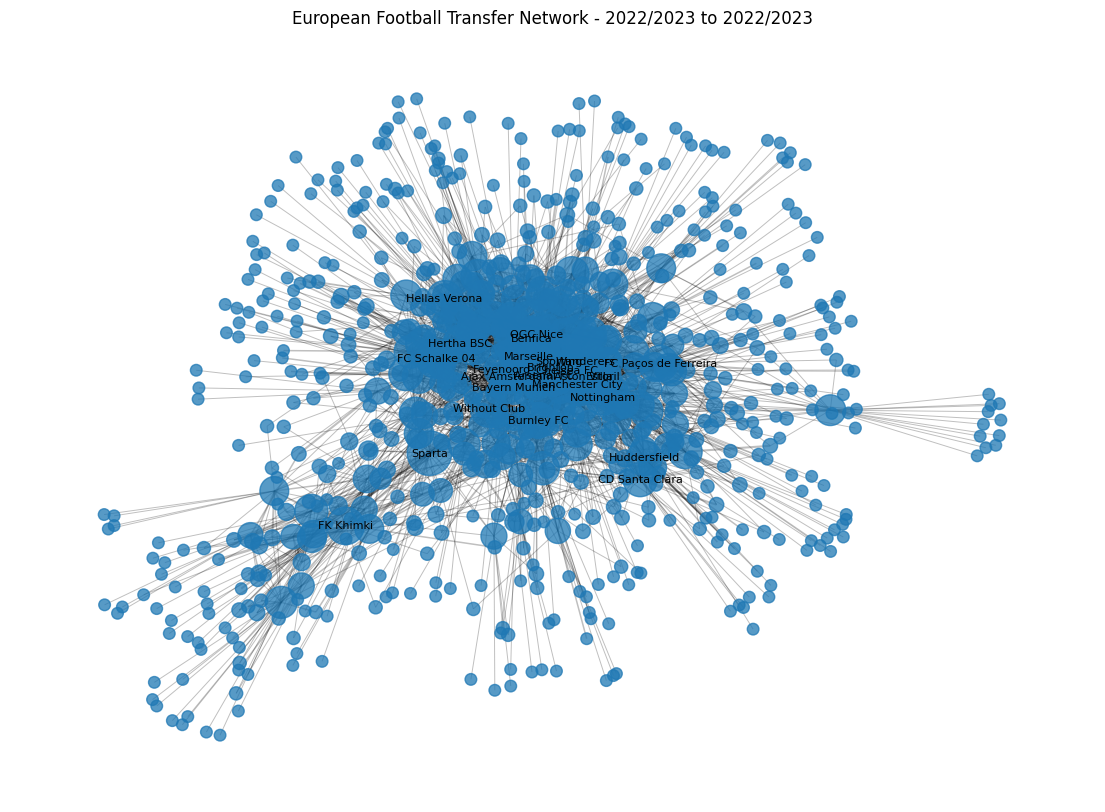

In [50]:
# Plotting the Network
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    G,
    k=0.25,
    iterations=50,
    seed=42,
    weight="weight"
)

node_sizes = [50 + 20 * G.degree(node) for node in G.nodes()]
edge_widths = [0.3 + 0.4 * G[u][v]["weight"] for u, v in G.edges()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.75
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.25
)

# Label only the most connected clubs
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:25]
labels = {node: node for node, degree in top_nodes}

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=8
)

plt.title(f"European Football Transfer Network - {seasons_to_plot[0]} to {seasons_to_plot[-1]}")
plt.axis("off")
plt.show()

### 4. Basic Network Characterization

Here we study basic metrics to obtain useful information that allows us to have an idea of what the network looks like, and describe its basic structure.

In [51]:
print("Number of nodes: ", G.number_of_nodes())
print("Number of edges: ", G.number_of_edges())
print("Density: ", nx.density(G))
print("Average clustering: ", nx.average_clustering(G))
print("Number of connected components: ", nx.number_connected_components(G))

Number of nodes:  769
Number of edges:  2540
Density:  0.008601538794971825
Average clustering:  0.0912297289148891
Number of connected components:  1


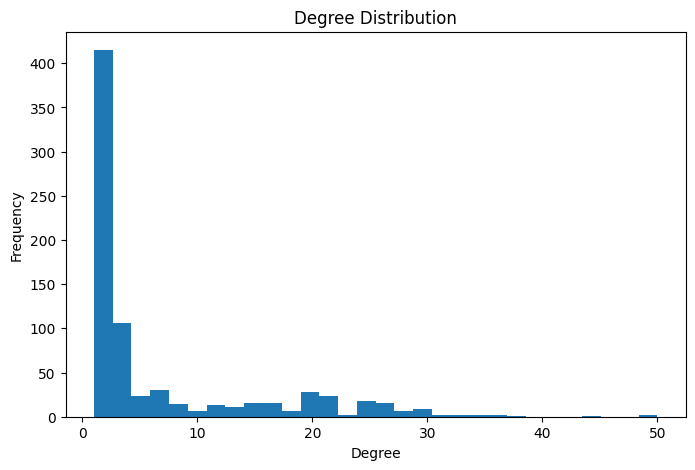

In [52]:
# Plotting the degree distribution of our Network

degrees = [d for n, d in G.degree()]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    degrees,
    bins=30
)

plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution")

plt.show()

In [53]:
# Checking which clubs are hubs of our network (clubs that have the most amount of transfers during that season)
top_degree_nodes = sorted(
    G.degree, # this functionality returns pairs (node, degree)
    key=lambda x: x[1], # we order the list of pairs by the second value of the pair (the degree)
    reverse=True # we order from high to low
)[:20] # we take the top 20 teams

top_degree_nodes

[('Benfica', 50),
 ('Sparta', 49),
 ('Sporting', 44),
 ('FC Schalke 04', 37),
 ('Arsenal FC', 36),
 ('Manchester City', 36),
 ('Chelsea FC', 34),
 ('FK Khimki', 34),
 ('Marseille', 33),
 ('Without Club', 33),
 ('OGC Nice', 31),
 ('FC Paços de Ferreira', 31),
 ('Hellas Verona', 30),
 ('Wanderers', 30),
 ('Burnley FC', 30),
 ('Estoril', 30),
 ('Huddersfield', 30),
 ('Nottingham', 30),
 ('Brighton', 29),
 ('Hertha BSC', 29)]

### 5. Community Detection



In [54]:
pip install python-louvain

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
# Applying Louvain Algorithm

import community as community_louvain  # pip install python-louvain

# Louvain partition
partition = community_louvain.best_partition(
    G,
    weight='weight',   # usa los pesos de las aristas
    random_state=42
)

# partition es un diccionario: nodo -> comunidad
list(partition.items())[:20]

[('Cádiz', 0),
 ('Real Valladolid CF', 0),
 ('Krylya Sovetov Samara', 1),
 ('Sparta', 1),
 ('Brighton', 2),
 ('Fulham', 2),
 ('Ural', 1),
 ('Real Madrid', 0),
 ('Cardiff', 2),
 ('West Brom', 2),
 ('Corinthians', 1),
 ('Zenit', 1),
 ('Arsenal FC', 3),
 ('Marseille', 3),
 ('AFC Bournemouth', 2),
 ('Stoke', 2),
 ('KS Samara', 1),
 ('Fortuna', 4),
 ('MVV', 4),
 ('Girona FC', 0)]

D:\Temp\ipykernel_18080\3821008453.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


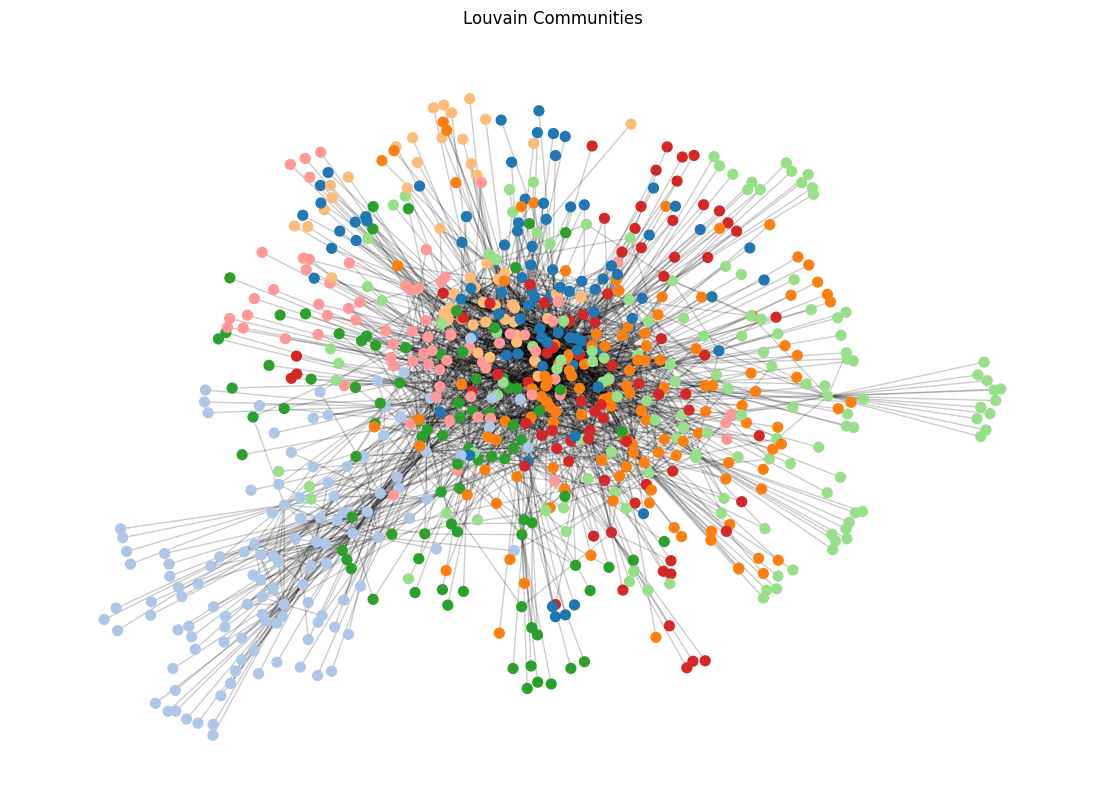

In [56]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import networkx as nx

# Colores
cmap = cm.get_cmap('tab20')

plt.figure(figsize=(14,10))
pos = nx.spring_layout(G, seed=42, weight='weight')

nx.draw_networkx_nodes(
    G, pos,
    node_color=[cmap(partition[n] % 20) for n in G.nodes()],
    node_size=50
)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Louvain Communities")
plt.axis("off")
plt.show()

In [57]:
from collections import defaultdict

# Grouping clubs by community
communities = defaultdict(list)

for club, community_id in partition.items():
    communities[community_id].append(club)

# Printing communities
for community_id, clubs in communities.items():
    
    print(f"\nCOMMUNITY {community_id}")
    print(f"Number of clubs: {len(clubs)}")
    print(sorted(clubs))


COMMUNITY 0
Number of clubs: 85
['1.FC Magdeburg', 'AS Nancy', 'Adana Demirspor', 'Al-Ahli SC', 'Albacete', 'América', 'Arsenal Sarandí', 'Aston Villa', 'Athletic', 'Atletico de Madrid', 'Basaksehir', 'Burgos CF', 'CA Osasuna', 'CD Alcoyano', 'CD Leganés', 'CD Logroñés', 'CD Lugo', 'CD Mirandés', 'CD Tenerife', 'CF Fuenlabrada', 'Cartagena FC', 'Celta', 'Central', 'CyD Leonesa', 'Cádiz', 'Dep. La Coruña', 'Depor', 'Dundee United', 'Dynamo 2 Kyiv', 'Elche CF', 'Elche Ilicitano', 'Envigado', 'FC Barcelona', 'FC Juárez', 'FC Lugano', 'Fluminense', 'Galatasaray', 'Getafe', 'Girona FC', 'Granada 74 CF', 'Heart of Midl.', 'Independiente', 'Júbilo Iwata', 'Karagümrük', 'Kilmarnock FC', 'Levante UD', 'Mallorca', 'Monterrey', 'Málaga', 'New York City', 'New York RB', 'Oviedo', 'PAS Giannina', 'PAS Lamia', 'Peñarol', 'RCD Espanyol', 'Racing Santander', 'Rayo', 'Real Cartagena', 'Real Madrid', 'Real Sociedad', 'Real Valladolid CF', 'Real Zaragoza', 'Rushden & Diam.', 'SCR Altach', 'SD Amorebieta

In [58]:
from collections import Counter

for community_id, clubs in communities.items():
    
    league_counts = Counter(
        club_to_league.get(club, "Unknown")
        for club in clubs
    )
    
    print(f"\nCOMMUNITY {community_id}")
    print(f"Number of clubs: {len(clubs)}")
    
    print("\nLeague composition:")
    
    for league, count in league_counts.most_common():
        print(f"{league}: {count}")


COMMUNITY 0
Number of clubs: 85

League composition:
Unknown: 49
spanish_laliga: 30
english_premier_league: 3
italian_serieA: 1
german_bundesliga: 1
french_ligue1: 1

COMMUNITY 1
Number of clubs: 122

League composition:
Unknown: 95
russian_premier_liga: 24
german_bundesliga: 2
dutch_eredivisie: 1

COMMUNITY 2
Number of clubs: 133

League composition:
Unknown: 82
english_premier_league: 39
english_championship: 10
french_ligue1: 1
italian_serieA: 1

COMMUNITY 3
Number of clubs: 51

League composition:
italian_serieA: 27
Unknown: 22
english_premier_league: 1
french_ligue1: 1

COMMUNITY 4
Number of clubs: 89

League composition:
Unknown: 59
dutch_eredivisie: 26
german_bundesliga: 2
french_ligue1: 1
italian_serieA: 1

COMMUNITY 5
Number of clubs: 140

League composition:
Unknown: 105
portugese_ligaNOS: 28
spanish_laliga: 3
english_premier_league: 2
french_ligue1: 2

COMMUNITY 6
Number of clubs: 77

League composition:
Unknown: 45
french_ligue1: 31
dutch_eredivisie: 1

COMMUNITY 7
Number 

In [59]:
# Community 0: Spanish
# Community 1: Russian
# Community 2: German & Dutch
# Community 3: Italian
# Community 4: Portuguese
# Community 5: English
# Community 6: French

In [60]:
# Applying Greedy Modularity (Clauset-Newman-Moore) Algorithm
from networkx.algorithms import community

cnm_communities = community.greedy_modularity_communities(G, weight='weight')

partition_cnm = {}
for i, comm in enumerate(cnm_communities):
    for node in comm:
        partition_cnm[node] = i

list(partition_cnm.items())[:20]

[('Bristol', 0),
 ('HB Köge', 0),
 ('Livingston FC', 0),
 ('Watford', 0),
 ('FSV Zwickau', 0),
 ('Hampton & Rich.', 0),
 ('Coventry', 0),
 ('FC Barcelona', 0),
 ('Wanderers', 0),
 ('Maidstone', 0),
 ('Plymouth', 0),
 ('Sheffield United', 0),
 ('Colchester', 0),
 ('Manchester City', 0),
 ('Forest Green', 0),
 ('Galatasaray', 0),
 ('KV Kortrijk', 0),
 ('Standard', 0),
 ('Molde', 0),
 ('Oxford United', 0)]

D:\Temp\ipykernel_18080\1050599013.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


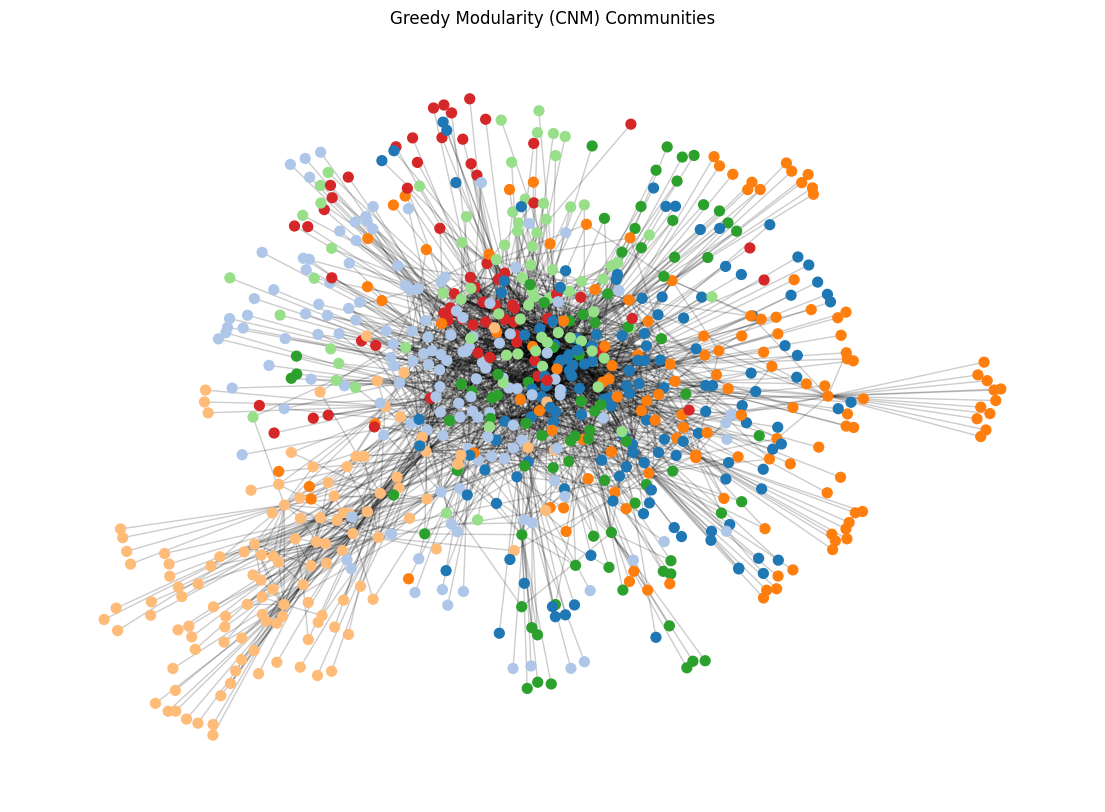

In [61]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import networkx as nx

# Colores
cmap = cm.get_cmap('tab20')

plt.figure(figsize=(14,10))
pos = nx.spring_layout(G, seed=42, weight='weight')

nx.draw_networkx_nodes(
    G, pos,
    node_color=[cmap(partition_cnm[n] % 20) for n in G.nodes()],
    node_size=50
)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Greedy Modularity (CNM) Communities")
plt.axis("off")
plt.show()

In [62]:
from collections import defaultdict

# Grouping clubs by community
communities_cnm = defaultdict(list)

for club, community_id in partition_cnm.items():
    communities_cnm[community_id].append(club)

# Printing communities
for community_id, clubs in communities_cnm.items():
    
    print(f"\nCOMMUNITY {community_id}")
    print(f"Number of clubs: {len(clubs)}")
    print(sorted(clubs))


COMMUNITY 0
Number of clubs: 146
['AFC Bournemouth', 'AFC Wimbledon', 'Accrington', 'Adana Demirspor', 'Aldershot', 'Altay SK', 'Antalyaspor', 'Aston Villa', 'Athletic', 'Barnsley', 'Besiktas', 'Birmingham', 'Blackburn', 'Blackpool', 'Boston Utd', 'Brentford', 'Brighton', 'Bristol', 'Burnley FC', 'Burton', 'Cardiff', 'Cavalry FC', 'Central', 'Charlton', 'Chelsea FC', 'Cheltenham', 'Chicago', 'Colchester', 'Como', 'Coventry', 'Crawley Town', 'Crystal Palace', 'Degerfors', 'Derby', 'Dorking', 'Dundee United', 'East Preston', 'Envigado', 'Everton', 'FC Barcelona', 'FC Midtjylland', 'FC São Paulo', 'FC Winterthur', 'FSV Zwickau', 'Fleetwood', 'Forest Green', 'Fulham', 'Galatasaray', 'Grasshoppers', 'Grimsby', 'Guanacasteca', 'HB Köge', 'Hampton & Rich.', 'Harrogate Town', 'Hatayspor', 'Heart of Midl.', 'Herediano', 'Hibernian FC', 'Huddersfield', 'Hull', 'Ipswich', 'KV Kortrijk', 'KVC Westerlo', 'Kidderminster', 'LD Alajuelense', 'Leeds', 'Leicester City', 'Lewes', 'Leyton Orient', 'Liber

In [64]:
from collections import Counter

for community_id, clubs in communities_cnm.items():
    
    league_counts = Counter(
        club_to_league.get(club, "Unknown")
        for club in clubs
    )
    
    print(f"\nCOMMUNITY {community_id}")
    print(f"Number of clubs: {len(clubs)}")
    
    print("\nLeague composition:")
    
    for league, count in league_counts.most_common():
        print(f"{league}: {count}")


COMMUNITY 0
Number of clubs: 146

League composition:
Unknown: 90
english_premier_league: 43
english_championship: 10
spanish_laliga: 1
french_ligue1: 1
italian_serieA: 1

COMMUNITY 1
Number of clubs: 142

League composition:
Unknown: 86
german_bundesliga: 28
dutch_eredivisie: 24
french_ligue1: 2
russian_premier_liga: 1
italian_serieA: 1

COMMUNITY 2
Number of clubs: 135

League composition:
Unknown: 104
portugese_ligaNOS: 27
french_ligue1: 2
spanish_laliga: 1
english_premier_league: 1

COMMUNITY 3
Number of clubs: 121

League composition:
Unknown: 94
russian_premier_liga: 23
dutch_eredivisie: 3
german_bundesliga: 1

COMMUNITY 4
Number of clubs: 84

League composition:
Unknown: 55
french_ligue1: 28
german_bundesliga: 1

COMMUNITY 5
Number of clubs: 75

League composition:
Unknown: 41
spanish_laliga: 32
dutch_eredivisie: 1
portugese_ligaNOS: 1

COMMUNITY 6
Number of clubs: 66

League composition:
Unknown: 32
italian_serieA: 28
french_ligue1: 4
russian_premier_liga: 1
english_premier_le

In [ ]:
# Applying Greedy Modularity (Clauset-Newman-Moore) Algorithm
from networkx.algorithms import community

cnm_communities = community.greedy_modularity_communities(G, weight='weight')

partition_cnm = {}
for i, comm in enumerate(cnm_communities):
    for node in comm:
        partition_cnm[node] = i

list(partition_cnm.items())[:20]

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import networkx as nx

# Colores
cmap = cm.get_cmap('tab20')

plt.figure(figsize=(14,10))
pos = nx.spring_layout(G, seed=42, weight='weight')

nx.draw_networkx_nodes(
    G, pos,
    node_color=[cmap(partition_cnm[n] % 20) for n in G.nodes()],
    node_size=50
)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Greedy Modularity (CNM) Communities")
plt.axis("off")
plt.show()

In [ ]:
from collections import defaultdict

# Grouping clubs by community
communities_cnm = defaultdict(list)

for club, community_id in partition_cnm.items():
    communities_cnm[community_id].append(club)

# Printing communities
for community_id, clubs in communities_cnm.items():
    
    print(f"\nCOMMUNITY {community_id}")
    print(f"Number of clubs: {len(clubs)}")
    print(sorted(clubs))

In [ ]:
from collections import Counter

for community_id, clubs in communities_cnm.items():
    
    league_counts = Counter(
        club_to_league.get(club, "Unknown")
        for club in clubs
    )
    
    print(f"\nCOMMUNITY {community_id}")
    print(f"Number of clubs: {len(clubs)}")
    
    print("\nLeague composition:")
    
    for league, count in league_counts.most_common():
        print(f"{league}: {count}")